# 03 · SHAP: what drives the points model

`shap.TreeExplainer` on the production LightGBM (`data/published/model.txt`, L2, 106 trees).
TreeSHAP is exact for tree models: for every row, `base value + Σ SHAP = prediction`
(points **per fixture**). The global view uses a 5,000-row sample of 2025-26, the season where
every feature (xG, DEFCON, odds, Elo) is populated.

Regenerate the saved images with `python -m fPLense.pipeline --explain`.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from fPLense import config
from fPLense.models import explain, train

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)

df = train.load_features()
model = explain.load_model()
sample = explain.sample_rows(df)
expl = explain.explain(model, sample)
print(f"{len(sample):,} rows of {config.SHAP_SAMPLE_SEASON}, base value {expl.base_values[0]:.3f}")

5,000 rows of 2025-26, base value 1.247


## Additivity check
SHAP values plus the base value reproduce the model's prediction to machine precision.

In [2]:
pred = model.predict(train.lgbm_frame(sample))
recon = expl.values.sum(axis=1) + expl.base_values
print(f"max |prediction - (base + Σ SHAP)| = {np.abs(pred - recon).max():.2e}")

max |prediction - (base + Σ SHAP)| = 7.55e-15


## Global importance (mean |SHAP|)

In [3]:
imp = explain.importance(expl)
group_of = {f: g for g, fs in config.FEATURE_GROUPS.items() for f in fs}
imp_df = imp.rename("mean_abs_shap").to_frame().assign(group=lambda d: d.index.map(group_of))
print(imp_df.head(15).round(3).to_string())
print()
print(imp_df.groupby("group")["mean_abs_shap"].sum().sort_values(ascending=False).round(3))

                   mean_abs_shap        group
minutes_r3                 0.575      minutes
pts_last1                  0.246         form
pts_season_avg             0.146         form
price                      0.084       market
pts_r3                     0.081         form
ict_r5                     0.047         form
p_win                      0.046     odds_elo
minutes_r5                 0.038      minutes
log_selected_lag1          0.033       market
fdr                        0.026      fixture
p_clean_sheet              0.026     odds_elo
opp_xg_implied             0.022     odds_elo
defcon_r5                  0.018    defensive
position                   0.017  categorical
threat_r5                  0.012    attacking

group
minutes        0.619
form           0.532
market         0.130
odds_elo       0.106
fixture        0.047
attacking      0.030
defensive      0.026
categorical    0.020
Name: mean_abs_shap, dtype: float64


**Takeaway:** minutes and role dominate. `minutes_r3` alone (mean |SHAP| 0.58 points per fixture) is more than twice the next feature (`pts_last1`, 0.25); the minutes and form groups together carry ~1.15 of the ~1.5 total. Price (a proxy for quality) and the odds-based `p_win` / `p_clean_sheet` come next. The xG features are individually tiny (`xgi_r5` 0.003): ICT/threat and points form already carry most of what they say, which matches the P3 ablation (+ xG moved MAE by only 0.007). Odds/Elo get real SHAP mass (~0.11) yet added nothing in the ablation: they *substitute* for FDR and opponent form rather than add new information.

## Beeswarm

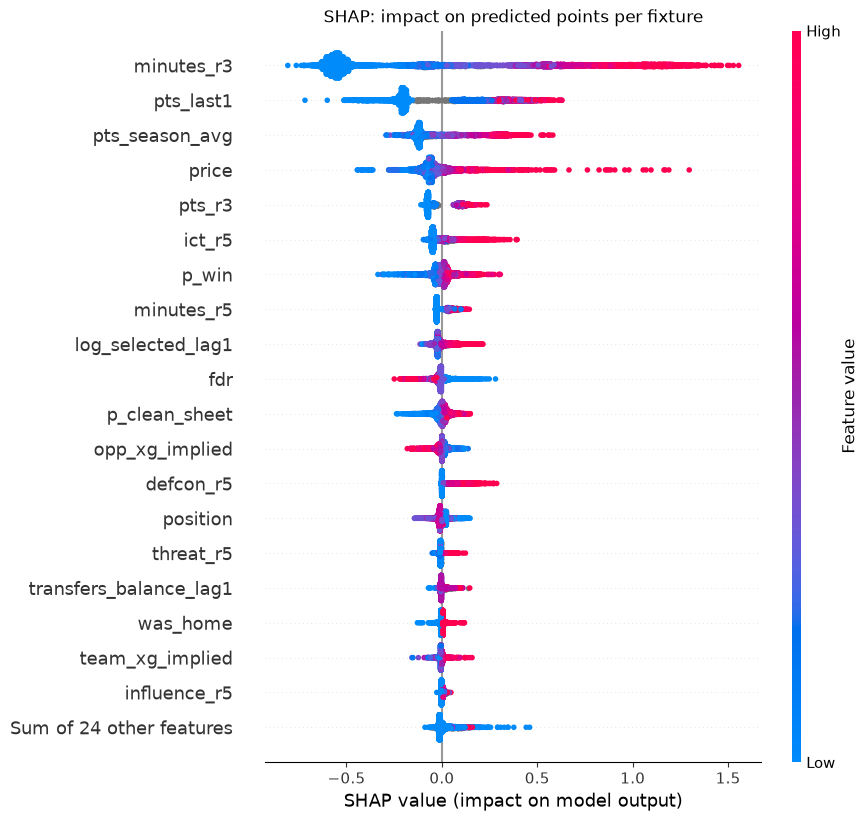

In [4]:
shap.plots.beeswarm(expl, max_display=20, show=False)
plt.title("SHAP: impact on predicted points per fixture")
plt.show()

**Takeaway:** the shape is asymmetric. Low `minutes_r3` pushes predictions down by up to ~0.8 points (rotation / bench players), while high minutes lifts them by up to ~1.5. Form features act mostly on the upside (a big last score raises the forecast; a blank barely lowers it). `defcon_r5` only ever adds: high DEFCON form lifts defenders by up to ~0.3, low values sit at ~0.

## Dependence plots: minutes, xGI form, fixture difficulty

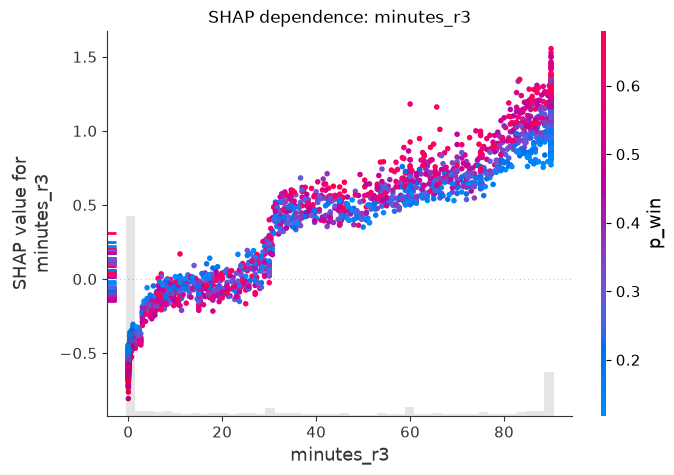

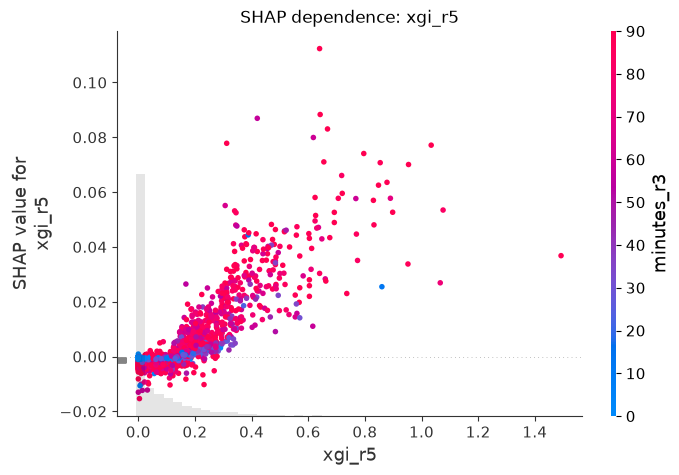

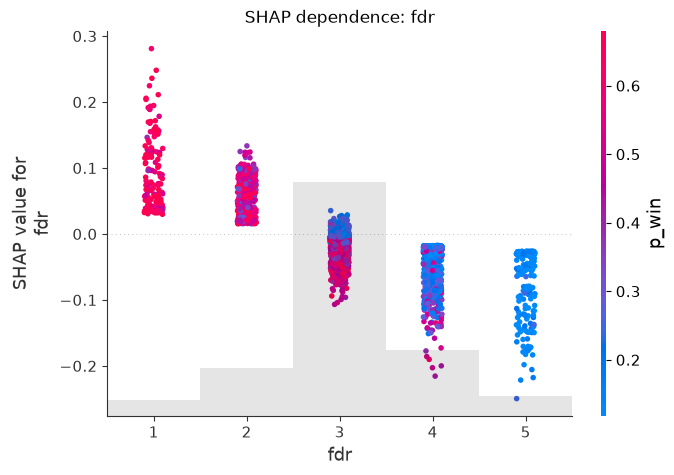

In [5]:
for f in config.SHAP_DEPENDENCE_FEATURES:
    shap.plots.scatter(expl[:, f], color=expl, show=False)
    plt.title(f"SHAP dependence: {f}")
    plt.show()

**Takeaway:** `minutes_r3` is close to a step function with a jump around 30 minutes (sub vs starter) and a steady climb to 90; higher `p_win` (colour) adds on top. `xgi_r5` rises roughly linearly up to ~0.6 per match, then flattens, and its effect is small (≤ 0.1). FDR behaves as expected: easy fixtures (1–2) add ~0.05–0.25, hard ones (4–5) subtract up to ~0.25, and the colour shows FDR and `p_win` move together.

## Waterfalls: one premium forward, one budget defender
Both from 2025-26 GW38 (the last gameweek): the priciest regular FWD, and the regular DEF priced
≤ £4.5m with the highest prediction. The final model was trained on this season, so these explain
the model, they don't evaluate it.

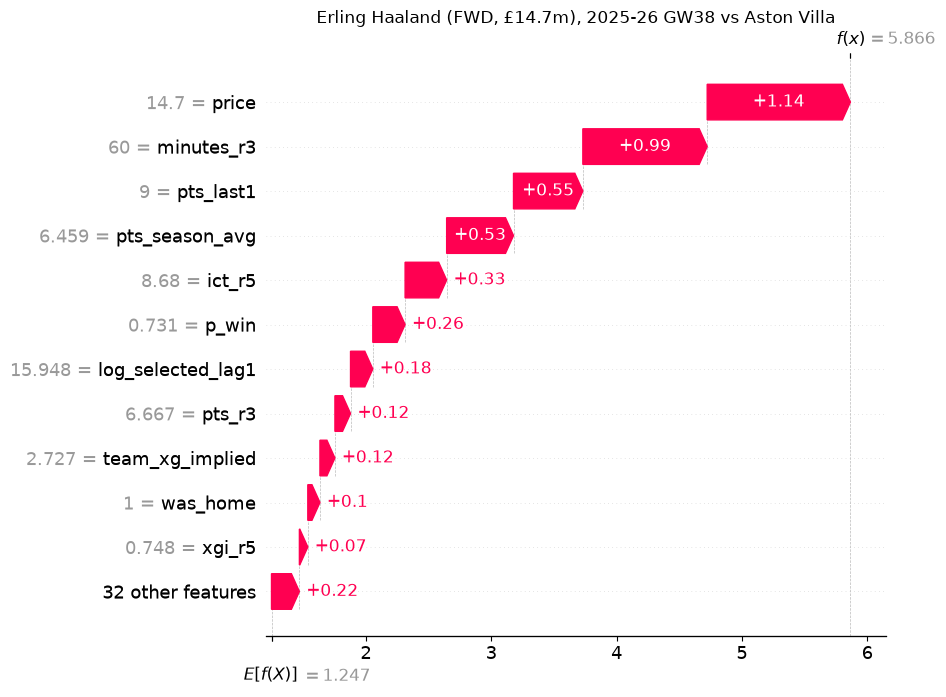

premium_fwd: predicted 5.87, actual 0


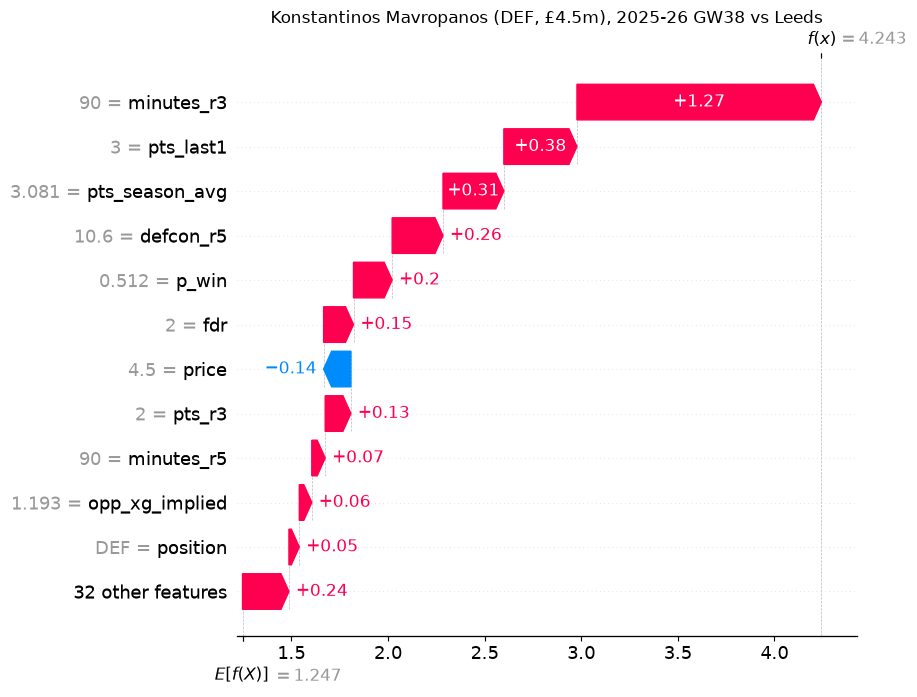

budget_def: predicted 4.24, actual 8


In [6]:
examples = explain.pick_examples(df, model)
ex = pd.DataFrame(examples).T
ex_expl = explain.explain(model, ex)
for k, (key, row) in enumerate(examples.items()):
    title = (
        f"{row['name']} ({row['position']}, £{float(row['price']):.1f}m), "
        f"{row['season']} GW{int(row['gw'])} vs {row['opponent_team_name']}"
    )
    shap.plots.waterfall(ex_expl[k], max_display=12, show=False)
    plt.title(title)
    plt.show()
    print(f"{key}: predicted {ex_expl[k].base_values + ex_expl[k].values.sum():.2f}, "
          f"actual {row[config.TARGET]:.0f}")

**Takeaway:** Haaland's 5.9-point forecast is built from price (+1.1), nailed-on minutes (+1.0) and recent hauls (+0.55 from `pts_last1`, +0.53 from the season average), plus a home fixture with a 73% win probability. He scored 0, a reminder of how noisy single fixtures are. Mavropanos (£4.5m) gets most of his 4.2 points from 90-minute starts (+1.27) and DEFCON form (+0.26 from 10.6 defensive actions per match); his low price *lowers* the forecast (−0.14). He scored 8.

## Per-row SHAP for the app
`explain.shap_frame` (LightGBM's built-in TreeSHAP, identical values) and
`explain.top_contributions` are what P5 writes next to each published prediction.

In [7]:
sv = explain.shap_frame(model, ex)
print(np.allclose(sv.drop(columns="base_value").to_numpy(), ex_expl.values))
for key, top in zip(examples, explain.top_contributions(sv), strict=True):
    print(key, top)

True
premium_fwd [('price', 1.143), ('minutes_r3', 0.992), ('pts_last1', 0.553), ('pts_season_avg', 0.533), ('ict_r5', 0.332)]
budget_def [('minutes_r3', 1.265), ('pts_last1', 0.378), ('pts_season_avg', 0.315), ('defcon_r5', 0.263), ('p_win', 0.2)]
